# Анализ данных интернет-магазина

Этот notebook содержит детальный анализ данных заказов интернет-магазина из PostgreSQL базы данных.

## 1. Подключение к базе данных и загрузка библиотек

In [1]:
# Установка необходимых библиотек
!pip install psycopg2-binary sqlalchemy pandas numpy matplotlib seaborn plotly -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Все библиотеки загружены успешно!")

Все библиотеки загружены успешно!


In [3]:
# Параметры подключения к PostgreSQL
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': 'ecommerce',
    'user': 'ecommerce_user',
    'password': 'ecommerce_pass_2024'
}

# Создание подключения
connection_string = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
engine = create_engine(connection_string)

print("Подключение к базе данных создано")

Подключение к базе данных создано


## 2. Загрузка данных из базы

In [4]:
# Загрузка всех данных из таблицы orders
query = """
SELECT 
    id,
    order_date,
    product_name,
    category,
    price,
    quantity,
    city,
    customer_age,
    payment_method,
    delivery_days,
    total_amount
FROM orders
ORDER BY order_date DESC;
"""

df = pd.read_sql(query, engine)

print(f"Загружено {len(df):,} заказов")
print(f"Период данных: с {df['order_date'].min()} по {df['order_date'].max()}")
df.head()

Загружено 3,385 заказов
Период данных: с 2026-01-24 15:16:32.940083 по 2026-01-24 17:04:19.901877


,id,order_date,product_name,category,price,quantity,city,customer_age,payment_method,delivery_days,total_amount
0,3385,2026-01-24 17:04:19.901877,Планшет iPad,Электроника,43800.0,2,Казань,35,СБП,3,87600.0
1,3384,2026-01-24 17:04:18.896259,Мастер и Маргарита,Книги,900.0,2,Владивосток,33,Карта,2,1800.0
2,3383,2026-01-24 17:04:17.892117,Мастер и Маргарита,Книги,1450.0,1,Нижний Новгород,49,СБП,3,1450.0
3,3382,2026-01-24 17:04:16.887696,Sapiens,Книги,1200.0,4,Челябинск,46,СБП,5,4800.0
4,3381,2026-01-24 17:04:15.882020,Планшет iPad,Электроника,129790.0,1,Ангарск,37,Карта,4,129790.0


In [5]:
# Информация о датасете
print("=" * 60)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"\nРазмер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"\nПериод данных: {(df['order_date'].max() - df['order_date'].min()).days} дней")
print(f"\nОбщая выручка: {df['total_amount'].sum():,.2f} ₽")
print(f"Средний чек: {df['total_amount'].mean():,.2f} ₽")
print(f"\nКатегории товаров: {df['category'].nunique()}")
print(f"Уникальных товаров: {df['product_name'].nunique()}")
print(f"Городов доставки: {df['city'].nunique()}")
print("\n" + "=" * 60)

ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер датасета: 3385 строк × 11 столбцов

Период данных: 0 дней

Общая выручка: 134,637,540.00 ₽
Средний чек: 39,774.75 ₽

Категории товаров: 5
Уникальных товаров: 37
Городов доставки: 14



In [6]:
# Проверка на пропущенные значения
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print("Пропущенные значения:")
    print(missing_values[missing_values > 0])
else:
    print("Пропущенных значений не обнаружено")

Пропущенных значений не обнаружено


## 3. Анализ продаж по категориям

In [7]:
# Агрегация по категориям
category_stats = df.groupby('category').agg({
    'id': 'count',
    'total_amount': ['sum', 'mean'],
    'quantity': 'sum'
}).round(2)

category_stats.columns = ['Количество заказов', 'Общая выручка', 'Средний чек', 'Продано единиц']
category_stats = category_stats.sort_values('Общая выручка', ascending=False)

print("Статистика по категориям:")
category_stats

Статистика по категориям:


,Количество заказов,Общая выручка,Средний чек,Продано единиц
category,,,,
Электроника,717,64501810.0,89960.68,818
Дом и сад,644,30087110.0,46719.11,739
Спорт,699,26052800.0,37271.53,983
Одежда,664,12170890.0,18329.65,936
Книги,661,1824930.0,2760.86,1043


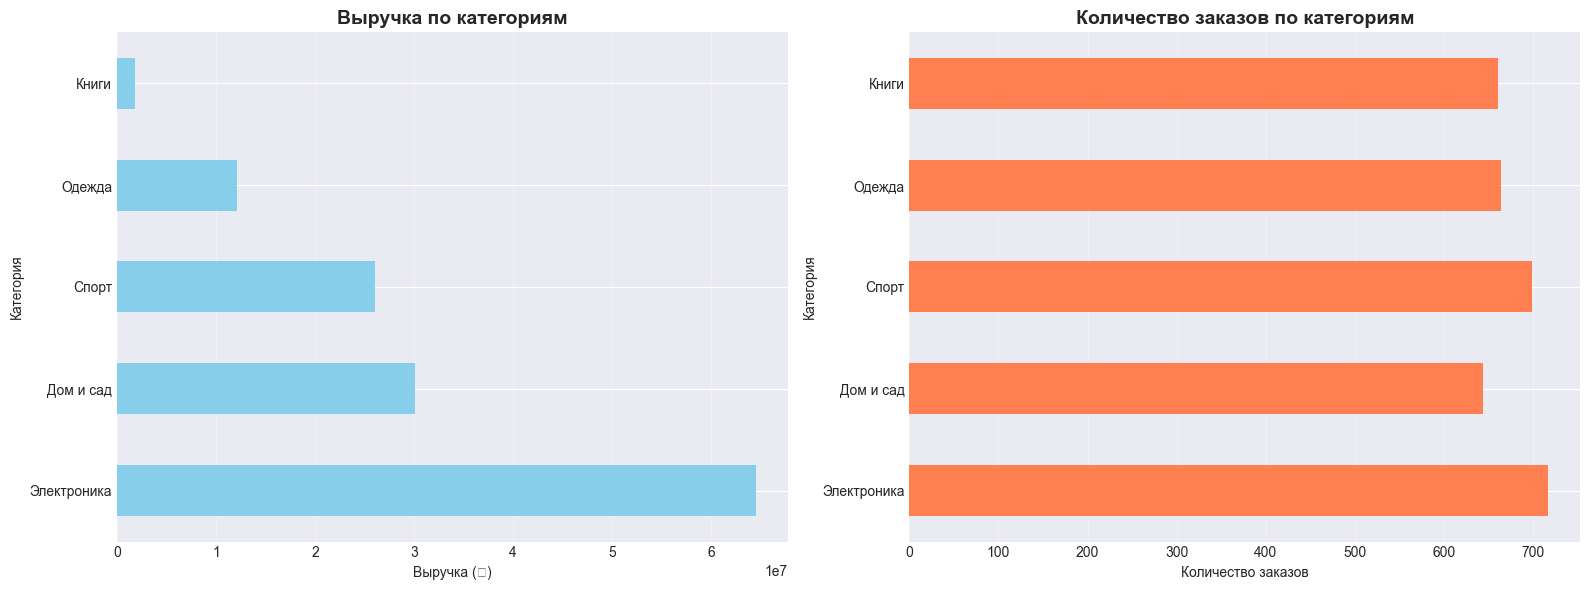


Самая прибыльная категория: Электроника
Самая популярная категория: Электроника


In [8]:
# Визуализация: выручка по категориям
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Выручка по категориям
category_stats['Общая выручка'].plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Выручка по категориям', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Выручка (₽)')
axes[0].set_ylabel('Категория')
axes[0].grid(axis='x', alpha=0.3)

# График 2: Количество заказов
category_stats['Количество заказов'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Количество заказов по категориям', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Категория')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nСамая прибыльная категория: {category_stats['Общая выручка'].idxmax()}")
print(f"Самая популярная категория: {category_stats['Количество заказов'].idxmax()}")

## 4. Анализ географии продаж

In [9]:
# ТОП-10 городов по выручке
city_stats = df.groupby('city').agg({
    'total_amount': 'sum',
    'id': 'count',
    'delivery_days': 'mean'
}).round(2)

city_stats.columns = ['Выручка', 'Заказов', 'Средний срок доставки']
city_stats = city_stats.sort_values('Выручка', ascending=False).head(10)

print("ТОП-10 городов по выручке:")
city_stats

ТОП-10 городов по выручке:


,Выручка,Заказов,Средний срок доставки
city,,,
Омск,10439360.0,247,3.07
Новосибирск,10291990.0,251,3.15
Екатеринбург,10207310.0,250,3.22
Казань,10174310.0,237,3.07
Владивосток,10113500.0,241,3.09
Ангарск,9794970.0,239,3.20
Красноярск,9787700.0,250,3.19
Уфа,9725370.0,262,3.04
Санкт-Петербург,9351170.0,241,1.64


In [10]:
# Визуализация городов
fig = px.bar(city_stats.reset_index(), 
             x='city', 
             y='Выручка',
             title='ТОП-10 городов по выручке',
             labels={'city': 'Город', 'Выручка': 'Выручка (₽)'},
             color='Выручка',
             color_continuous_scale='Blues')

fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()

## 5. Анализ способов оплаты

In [11]:
# Распределение способов оплаты
payment_stats = df.groupby('payment_method').agg({
    'id': 'count',
    'total_amount': ['sum', 'mean']
}).round(2)

payment_stats.columns = ['Количество', 'Общая сумма', 'Средний чек']
payment_stats['Доля (%)'] = (payment_stats['Количество'] / payment_stats['Количество'].sum() * 100).round(1)
payment_stats = payment_stats.sort_values('Количество', ascending=False)

print("Статистика по способам оплаты:")
payment_stats

Статистика по способам оплаты:


,Количество,Общая сумма,Средний чек,Доля (%)
payment_method,,,,
Карта,1947,73500190.0,37750.48,57.5
СБП,661,32247740.0,48786.29,19.5
Наличные,504,12292790.0,24390.46,14.9
Рассрочка,273,16596820.0,60794.21,8.1


In [12]:
# Pie chart для способов оплаты
fig = go.Figure(data=[go.Pie(
    labels=payment_stats.index,
    values=payment_stats['Количество'],
    hole=.3,
    marker_colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
)])

fig.update_layout(
    title='Распределение способов оплаты',
    height=500
)

fig.show()

## 6. Анализ клиентов по возрасту

In [13]:
# Создание возрастных групп
df['age_group'] = pd.cut(df['customer_age'], 
                         bins=[0, 25, 35, 45, 55, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56+'])

age_stats = df.groupby('age_group').agg({
    'id': 'count',
    'total_amount': ['sum', 'mean']
}).round(2)

age_stats.columns = ['Количество заказов', 'Общая выручка', 'Средний чек']

print("Статистика по возрастным группам:")
age_stats

Статистика по возрастным группам:


,Количество заказов,Общая выручка,Средний чек
age_group,,,
18-25,351,14426200.0,41100.28
26-35,710,27441640.0,38650.20
36-45,927,36941050.0,39850.11
46-55,726,28969670.0,39903.13
56+,671,26858980.0,40028.29


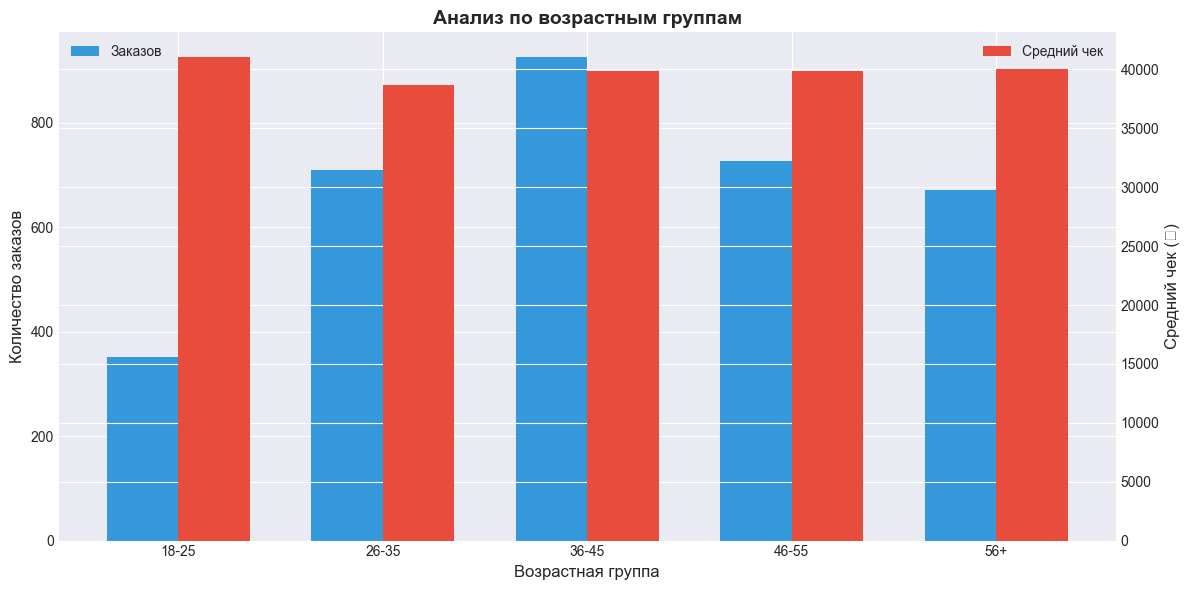

In [14]:
# Визуализация возрастных групп
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(age_stats.index))
width = 0.35

ax.bar(x - width/2, age_stats['Количество заказов'], width, label='Заказов', color='#3498db')
ax2 = ax.twinx()
ax2.bar(x + width/2, age_stats['Средний чек'], width, label='Средний чек', color='#e74c3c')

ax.set_xlabel('Возрастная группа', fontsize=12)
ax.set_ylabel('Количество заказов', fontsize=12)
ax2.set_ylabel('Средний чек (₽)', fontsize=12)
ax.set_title('Анализ по возрастным группам', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(age_stats.index)

ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 7. Корреляционный анализ

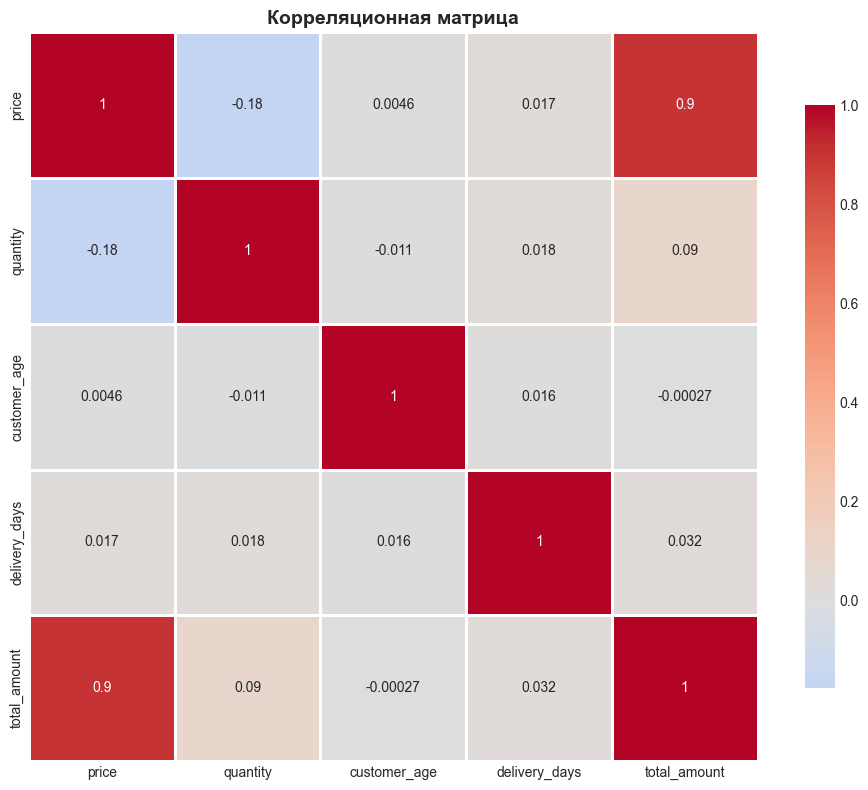


Сильные корреляции:
   price <-> total_amount: 0.90


In [15]:
# Корреляция числовых признаков
numeric_cols = ['price', 'quantity', 'customer_age', 'delivery_days', 'total_amount']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nСильные корреляции:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            print(f"   {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")

## 8. ТОП товаров

In [16]:
# ТОП-15 самых продаваемых товаров
top_products = df.groupby('product_name').agg({
    'id': 'count',
    'total_amount': 'sum',
    'quantity': 'sum'
}).sort_values('id', ascending=False).head(15)

top_products.columns = ['Продаж', 'Выручка', 'Единиц']

print("ТОП-15 самых продаваемых товаров:")
top_products

ТОП-15 самых продаваемых товаров:


,Продаж,Выручка,Единиц
product_name,,,
Наушники AirPods,151,13195370.0,176
Планшет iPad,149,13322380.0,163
Смартфон iPhone,144,12758110.0,171
Умные часы Apple Watch,143,12785290.0,162
Ноутбук MacBook,130,12440660.0,146
Sapiens,97,274790.0,156
Гантели,97,3466470.0,138
Ботинки,96,1857300.0,132
Коврик для йоги,93,3313680.0,127


In [17]:
# Визуализация топ товаров
fig = px.treemap(top_products.reset_index(), 
                 path=['product_name'], 
                 values='Выручка',
                 title='ТОП-15 товаров по выручке (Treemap)',
                 color='Выручка',
                 color_continuous_scale='Viridis')

fig.update_layout(height=600)
fig.show()

## Выводы и рекомендации

In [18]:
print("=" * 70)
print("ОСНОВНЫЕ ВЫВОДЫ ПО АНАЛИЗУ")
print("=" * 70)

# 1. Общая статистика
print(f"\nОБЩАЯ СТАТИСТИКА:")
print(f"   Всего заказов: {len(df):,}")
print(f"   Общая выручка: {df['total_amount'].sum():,.2f} ₽")
print(f"   Средний чек: {df['total_amount'].mean():,.2f} ₽")

# 2. Категории
print(f"\nКАТЕГОРИИ:")
top_category = category_stats['Общая выручка'].idxmax()
print(f"   Самая прибыльная категория: {top_category}")
print(f"   Доля выручки: {(category_stats.loc[top_category, 'Общая выручка'] / df['total_amount'].sum() * 100):.1f}%")

# 3. География
print(f"\nГЕОГРАФИЯ:")
top_city = city_stats['Выручка'].idxmax()
print(f"   Лидер по продажам: {top_city}")
print(f"   Средний срок доставки: {df['delivery_days'].mean():.1f} дней")

# 4. Способы оплаты
print(f"\nСПОСОБЫ ОПЛАТЫ:")
top_payment = payment_stats['Количество'].idxmax()
print(f"   Самый популярный: {top_payment}")
print(f"   Доля использования: {payment_stats.loc[top_payment, 'Доля (%)']}%")

# 5. Клиенты
print(f"\nКЛИЕНТЫ:")
print(f"   Средний возраст: {df['customer_age'].mean():.0f} лет")
print(f"   Самая активная группа: {age_stats['Количество заказов'].idxmax()}")

print("\n" + "=" * 70)
print("РЕКОМЕНДАЦИИ:")
print("=" * 70)
print(f"1. Увеличить ассортимент в категории '{top_category}' - она приносит больше всего выручки")
print(f"2. Оптимизировать логистику для топ-городов для сокращения сроков доставки")
print(f"3. Развивать популярные способы оплаты и стимулировать использование менее популярных")
print(f"4. Таргетировать маркетинг на возрастную группу {age_stats['Количество заказов'].idxmax()}")
print(f"5. Проводить промо-акции в часы пиковой активности")
print("=" * 70)

ОСНОВНЫЕ ВЫВОДЫ ПО АНАЛИЗУ

ОБЩАЯ СТАТИСТИКА:
   Всего заказов: 3,385
   Общая выручка: 134,637,540.00 ₽
   Средний чек: 39,774.75 ₽

КАТЕГОРИИ:
   Самая прибыльная категория: Электроника
   Доля выручки: 47.9%

ГЕОГРАФИЯ:
   Лидер по продажам: Омск
   Средний срок доставки: 2.9 дней

СПОСОБЫ ОПЛАТЫ:
   Самый популярный: Карта
   Доля использования: 57.5%

КЛИЕНТЫ:
   Средний возраст: 43 лет
   Самая активная группа: 36-45

РЕКОМЕНДАЦИИ:
1. Увеличить ассортимент в категории 'Электроника' - она приносит больше всего выручки
2. Оптимизировать логистику для топ-городов для сокращения сроков доставки
3. Развивать популярные способы оплаты и стимулировать использование менее популярных
4. Таргетировать маркетинг на возрастную группу 36-45
5. Проводить промо-акции в часы пиковой активности
